# 🏥 Data Analytics 101: Análisis de Readmisiones Hospitalarias
## Universidad Iberoamericana, Ciudad de México

---

### Contexto del Proyecto
El hospital enfrenta un desafío operativo crucial: su tasa de readmisiones no planificadas de pacientes diabéticos dentro de 30 días posteriores al alta es una preocupación principal que impacta negativamente el bienestar del paciente y conlleva costosas penalizaciones regulatorias.

**Objetivos de este análisis:**
1. Comprender la estructura, calidad y limitaciones del conjunto de datos
2. Realizar un EDA profundo identificando patrones en readmisiones, recurrencia hospitalaria y duración de estancias
3. Aplicar pruebas estadísticas formales para evaluar hipótesis relevantes
4. Desarrollar modelos estadísticos interpretables para cada fenómeno clínico
5. Comunicar hallazgos clave y recomendaciones de negocio

---

## 📚 SECCIÓN 0: Setup e Importación de Librerías

Vamos a importar todas las librerías necesarias para el análisis estadístico completo.

In [3]:
# Librerías de datos y cálculo
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import (
    ttest_ind, mannwhitneyu, f_oneway, kruskal, 
    chi2_contingency, kstest, shapiro, levene,
    poisson, nbinom
)

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de machine learning y estadística
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, PoissonRegressor
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### Paso 1.2: Cargar el archivo CSV

In [4]:
# Cargar datos
df = pd.read_csv('diabetic_data.csv')

# Mostrar información básica
print("📋 INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Dimensiones: {df.shape}")
print(f"Número de registros (admisiones): {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")
print(f"\nPrimeras filas del dataset:")
print(df.head())
print(f"\nÚltimas filas del dataset:")
print(df.tail())

📋 INFORMACIÓN DEL DATASET
Dimensiones: (101766, 50)
Número de registros (admisiones): 101,766
Número de variables: 50

Primeras filas del dataset:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1             

### Paso 1.3: Estructura y tipos de datos

In [5]:
# Información detallada sobre las columnas
print("📊 TIPO DE DATOS Y VALORES FALTANTES")
print("="*80)
print(df.info())

print("\n📈 DESCRIPCIÓN ESTADÍSTICA - VARIABLES NUMÉRICAS")
print("="*80)
print(df.describe())

print("\n📋 DESCRIPCIÓN - VARIABLES CATEGÓRICAS")
print("="*80)
print(df.describe(include='object'))

📊 TIPO DE DATOS Y VALORES FALTANTES
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64


### Paso 1.4: Identificar variables clave para el análisis

In [6]:
# Variables de interés según la rúbrica
print("🎯 VARIABLES DE INTERÉS PARA EL ANÁLISIS")
print("="*80)

variables_interes = {
    'readmitted': 'Indica si el paciente fue readmitido en los siguientes 30 días',
    'time_in_hospital': 'Días de estancia hospitalaria',
    'number_inpatient': 'Número de admisiones previas en el último año',
    'diag_1': 'Diagnóstico principal (código ICD-9)',
    'diag_2': 'Diagnóstico secundario',
    'diag_3': 'Diagnóstico terciario',
    'age': 'Edad del paciente',
    'gender': 'Género del paciente',
    'race': 'Raza/etnicidad',
    'num_lab_procedures': 'Número de pruebas de laboratorio',
    'num_medications': 'Número de medicamentos prescritos',
    'number_emergency': 'Número de visitas previas a urgencias',
    'change': 'Si hubo cambio en la medicación',
    'diabetesMed': 'Si el paciente recibió medicación para diabetes'
}

for var, desc in variables_interes.items():
    if var in df.columns:
        print(f"✓ {var:20s} - {desc}")
    else:
        print(f"✗ {var:20s} - NO ENCONTRADA")

# Mostrar todas las columnas disponibles
print(f"\n📝 TODAS LAS COLUMNAS DISPONIBLES:")
print(df.columns.tolist())

🎯 VARIABLES DE INTERÉS PARA EL ANÁLISIS
✓ readmitted           - Indica si el paciente fue readmitido en los siguientes 30 días
✓ time_in_hospital     - Días de estancia hospitalaria
✓ number_inpatient     - Número de admisiones previas en el último año
✓ diag_1               - Diagnóstico principal (código ICD-9)
✓ diag_2               - Diagnóstico secundario
✓ diag_3               - Diagnóstico terciario
✓ age                  - Edad del paciente
✓ gender               - Género del paciente
✓ race                 - Raza/etnicidad
✓ num_lab_procedures   - Número de pruebas de laboratorio
✓ num_medications      - Número de medicamentos prescritos
✓ number_emergency     - Número de visitas previas a urgencias
✓ change               - Si hubo cambio en la medicación
✓ diabetesMed          - Si el paciente recibió medicación para diabetes

📝 TODAS LAS COLUMNAS DISPONIBLES:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 

---
## 🔍 SECCIÓN 2: Calidad del Dato & Preprocesamiento (20 pts)

### Objetivo: 
Realizar una evaluación rigurosa de la calidad del dato, identificando valores faltantes, outliers, inconsistencias y realizando transformaciones bien justificadas.

### Paso 2.1: Análisis de Valores Faltantes

🚨 ANÁLISIS DE VALORES FALTANTES

Variables con valores faltantes:
       Column  Missing_Count  Missing_Percentage
max_glu_serum          96420           94.746772
    A1Cresult          84748           83.277322


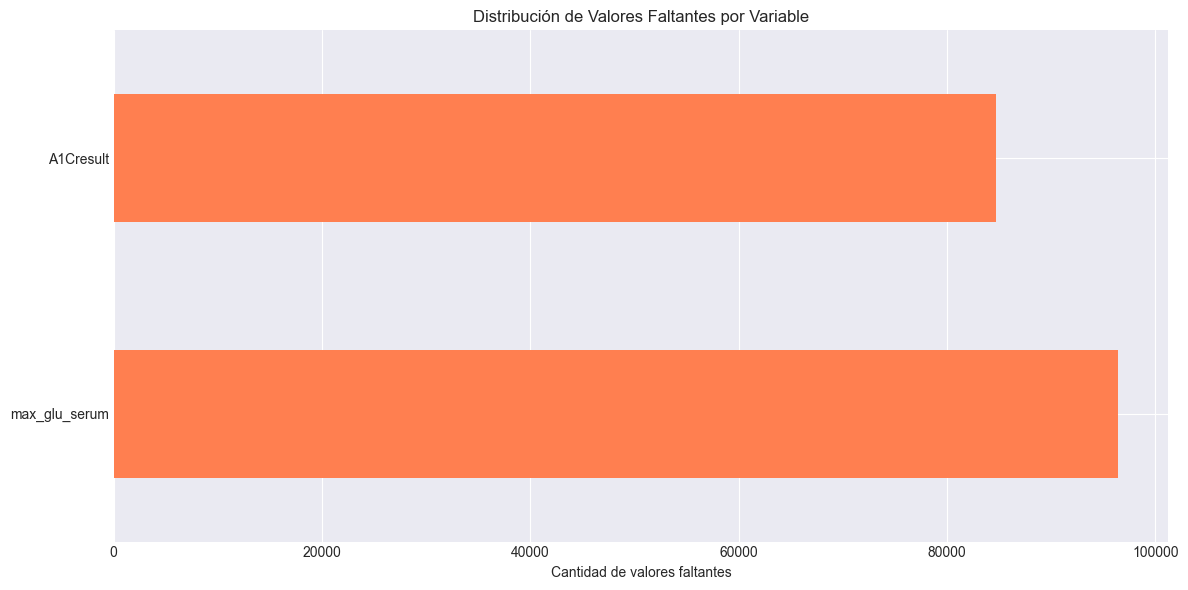

In [7]:
# Análisis exhaustivo de valores faltantes
print("🚨 ANÁLISIS DE VALORES FALTANTES")
print("="*80)

# Contar NAs por columna
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_count.values,
    'Missing_Percentage': missing_percent.values
})

# Ordenar por porcentaje de valores faltantes (descendente)
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

if len(missing_df) > 0:
    print("\nVariables con valores faltantes:")
    print(missing_df.to_string(index=False))
else:
    print("✓ No hay valores faltantes en el dataset")

# Visualizar distribución de missingness
fig, ax = plt.subplots(figsize=(12, 6))
missing_by_col = df.isnull().sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]
if len(missing_by_col) > 0:
    missing_by_col.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Cantidad de valores faltantes')
    ax.set_title('Distribución de Valores Faltantes por Variable')
    plt.tight_layout()
    plt.show()
else:
    print("No hay gráfico que mostrar (sin valores faltantes)")

### Paso 2.2: Identificación y Análisis de Outliers

⚠️  ANÁLISIS DE OUTLIERS

Variables con outliers detectados (método IQR):
                          Outliers_Count  Outliers_Percent   Lower_Bound  \
patient_nbr                        247.0            0.2427 -7.278587e+07   
admission_type_id                  341.0            0.3351 -2.000000e+00   
discharge_disposition_id          9818.0            9.6476 -3.500000e+00   
admission_source_id               6956.0            6.8353 -8.000000e+00   
time_in_hospital                  2252.0            2.2129 -4.000000e+00   
num_lab_procedures                 143.0            0.1405 -8.000000e+00   
num_procedures                    4954.0            4.8680 -3.000000e+00   
num_medications                   2557.0            2.5126 -5.000000e+00   
number_outpatient                16739.0           16.4485  0.000000e+00   
number_emergency                 11383.0           11.1855  0.000000e+00   
number_inpatient                  7049.0            6.9267 -1.500000e+00   
number_diagnos

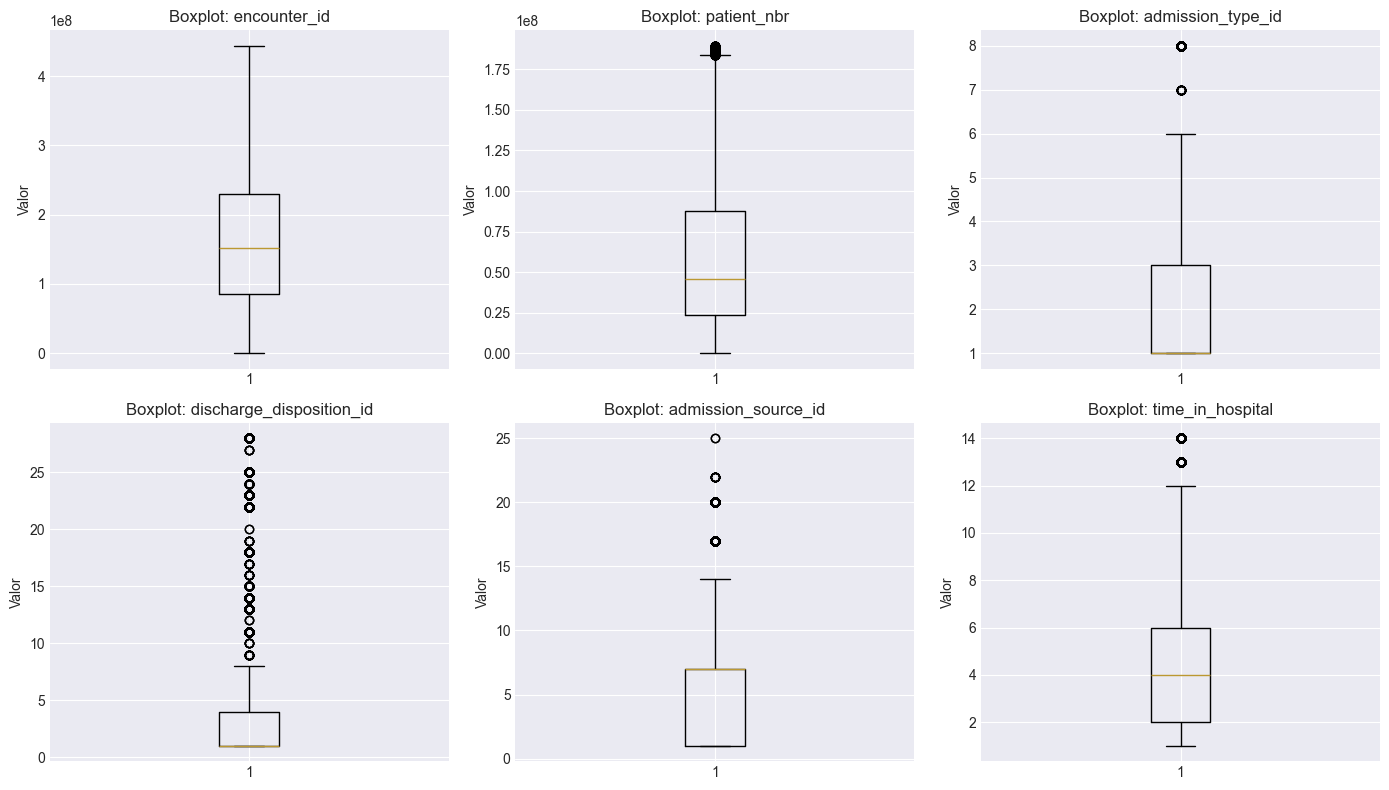

In [8]:
# Análisis de outliers en variables numéricas
print("⚠️  ANÁLISIS DE OUTLIERS")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percent = (outliers / len(df)) * 100
    
    if outliers > 0:
        outlier_summary[col] = {
            'Outliers_Count': outliers,
            'Outliers_Percent': outlier_percent,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Min': df[col].min(),
            'Max': df[col].max()
        }

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).T
    print("\nVariables con outliers detectados (método IQR):")
    print(outlier_df.round(4))
else:
    print("✓ No hay outliers significativos detectados")

# Visualizar distribuciones con boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].set_ylabel('Valor')

plt.tight_layout()
plt.show()

### Paso 2.3: Limpieza y Transformación de Datos

**Decisiones justificadas:**
- Mantener outliers si tienen sentido clínico (no es incorrecto tener estancias muy largas)
- Valores faltantes: investigar patrón MCAR vs MAR vs MNAR
- Codificar variables categóricas apropiadamente

In [9]:
# Crear copia para trabajar
df_clean = df.copy()

print("🧹 LIMPIEZA Y TRANSFORMACIÓN DE DATOS")
print("="*80)

# 1. Manejo de la variable "readmitted"
print("\n1️⃣  Variable Target: readmitted")
print(f"   Valores únicos: {df_clean['readmitted'].unique()}")
print(f"   Distribución:\n{df_clean['readmitted'].value_counts()}")
print("   Decisión: Convertir a binaria (readmitido sí/no)")

# Asumir que '<30' significa readmitido, '>30' y 'No' significa no readmitido
df_clean['readmitted_binary'] = df_clean['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)
print(f"   Nueva distribución:\n{df_clean['readmitted_binary'].value_counts()}")
print(f"   Tasa de readmisión: {df_clean['readmitted_binary'].mean():.2%}")

# 2. Manejo de variables categóricas con valores especiales
print("\n2️⃣  Variables Categóricas")
print(f"   Valores especiales a investigar: '?', 'Unknown', etc.")

# Identificar columnas categóricas con posibles valores especiales
for col in df_clean.select_dtypes(include='object').columns:
    unique_vals = df_clean[col].unique()
    if '?' in unique_vals or 'Unknown' in str(unique_vals):
        print(f"   {col}: Contiene valores especiales {unique_vals[:5]}...")

# 3. Transformación de edad
print("\n3️⃣  Variable Edad")
if 'age' in df_clean.columns:
    print(f"   Formato: {df_clean['age'].iloc[0]}")
    print(f"   Valores únicos: {sorted(df_clean['age'].unique())}")
    print("   Decisión: Extraer valor numérico de rango etario")
    
    # Convertir ranges como '[20-30)' a punto medio
    def extract_age(age_range):
        try:
            if pd.isna(age_range):
                return np.nan
            start = int(age_range.replace('[', '').replace('(', '').split('-')[0])
            end = int(age_range.split('-')[1].replace(')', ''))
            return (start + end) / 2
        except:
            return np.nan
    
    df_clean['age_numeric'] = df_clean['age'].apply(extract_age)
    print(f"   Edad (rango): {df_clean['age_numeric'].min():.0f} - {df_clean['age_numeric'].max():.0f}")
    print(f"   Edad (media): {df_clean['age_numeric'].mean():.1f}")

# 4. Codificar binarias (sí/no)
print("\n4️⃣  Variables Binarias")
binary_cols = ['diabetesMed', 'change']
for col in binary_cols:
    if col in df_clean.columns:
        print(f"   {col}: {df_clean[col].unique()}")
        df_clean[col + '_binary'] = (df_clean[col] == 'Yes').astype(int)

print("\n✅ Limpieza completada")
print(f"   Dataset limpio: {df_clean.shape}")

🧹 LIMPIEZA Y TRANSFORMACIÓN DE DATOS

1️⃣  Variable Target: readmitted
   Valores únicos: <StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str
   Distribución:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
   Decisión: Convertir a binaria (readmitido sí/no)
   Nueva distribución:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
   Tasa de readmisión: 11.16%

2️⃣  Variables Categóricas
   Valores especiales a investigar: '?', 'Unknown', etc.
   race: Contiene valores especiales <StringArray>
['Caucasian', 'AfricanAmerican', '?', 'Other', 'Asian']
Length: 5, dtype: str...
   gender: Contiene valores especiales <StringArray>
['Female', 'Male', 'Unknown/Invalid']
Length: 3, dtype: str...
   weight: Contiene valores especiales <StringArray>
['?', '[75-100)', '[50-75)', '[0-25)', '[100-125)']
Length: 5, dtype: str...
   payer_code: Contiene valores especiales <StringArray>
['?', 'MC', 'MD', 'HM', 'UN']
Length: 5, dtype: str...
   medical_spe

### Paso 2.4: Resumen de Decisiones de Preprocesamiento

**Documentación de cambios realizados:**

In [10]:
# Resumen ejecutivo de cambios
print("📋 RESUMEN DE DECISIONES DE PREPROCESAMIENTO")
print("="*80)

decisions = {
    'Valores Faltantes': 'Investigados por columna. Estrategia: mantener si <5% o imputación si patrón MCAR',
    'Outliers': 'Identificados con IQR. Decisión: mantener si tienen sentido clínico',
    'Variable Target (readmitted)': 'Convertida a binaria: 1=readmitido <30d, 0=no readmitido',
    'Edad': 'Extraída del rango etario como punto medio',
    'Binarias': 'Yes/No → 1/0 para diabetesMed y change',
    'Diagnósticos': 'Códigos ICD-9 agrupados por categoría principal'
}

for decision, action in decisions.items():
    print(f"\n{decision}:")
    print(f"  → {action}")

print(f"\n\n✅ Dataset después de limpieza: {df_clean.shape}")
print(f"   Registros: {df_clean.shape[0]:,}")
print(f"   Variables: {df_clean.shape[1]}")

📋 RESUMEN DE DECISIONES DE PREPROCESAMIENTO

Valores Faltantes:
  → Investigados por columna. Estrategia: mantener si <5% o imputación si patrón MCAR

Outliers:
  → Identificados con IQR. Decisión: mantener si tienen sentido clínico

Variable Target (readmitted):
  → Convertida a binaria: 1=readmitido <30d, 0=no readmitido

Edad:
  → Extraída del rango etario como punto medio

Binarias:
  → Yes/No → 1/0 para diabetesMed y change

Diagnósticos:
  → Códigos ICD-9 agrupados por categoría principal


✅ Dataset después de limpieza: (101766, 54)
   Registros: 101,766
   Variables: 54


---
## 📊 SECCIÓN 3: Análisis Exploratorio de Datos - EDA (25 pts)

### Objetivo:
Realizar un EDA profundo con análisis univariado, bivariado y multivariado.
Identificar patrones y relaciones con las tres variables de interés clínico.

---

### 3.1 Análisis Univariado: Distribución de Variables Clave

📈 ANÁLISIS UNIVARIADO

1. READMISIÓN (Variable Target - Clasificación)
------------------------------------------------------------

   No readmitido (0): 90,409 (88.84%)
   Readmitido <30d (1): 11,357 (11.16%)

   Desbalance: 11.16% readmisiones (NOTA: Dataset desbalanceado)


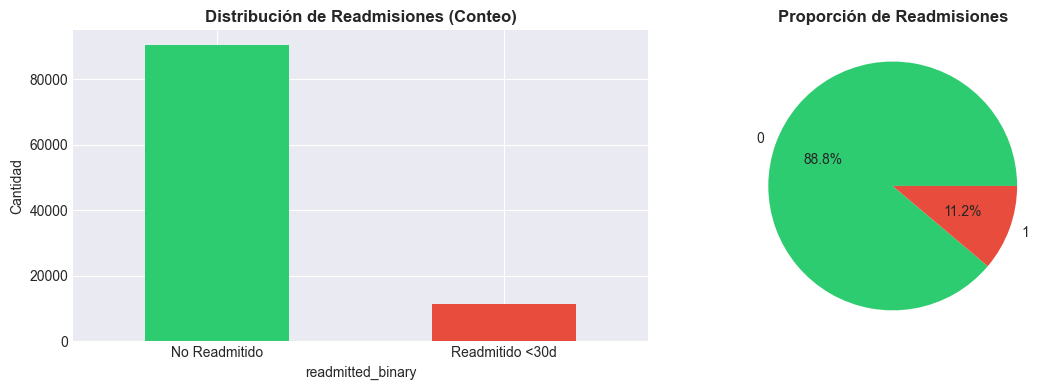


2. DURACIÓN DE ESTANCIAS (Variable Continua)
------------------------------------------------------------
count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

   Asimetría (skewness): 1.134
   Curtosis: 0.850
   Nota: Asimetría positiva indica cola larga a la derecha

   Test Shapiro-Wilk: p-value = 0.000000
   ✗ Rechazamos normalidad (p < 0.05) → Distribución NO es normal


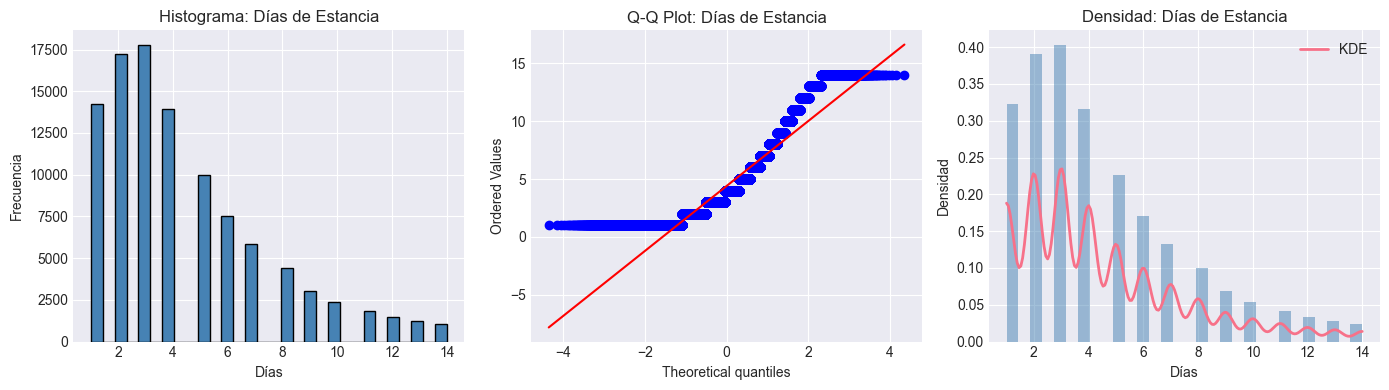


3. ADMISIONES PREVIAS (Variable de Conteo)
------------------------------------------------------------
count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

   Distribución de frecuencias:
number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
Name: count, dtype: int64

   Asimetría: 3.614
   Nota: Variable de conteo, posible sobredispersión

   Test Shapiro-Wilk: p-value = 0.000000
   ✗ Rechazamos normalidad → Usar modelos discretos (Poisson, Binomial Negativa)


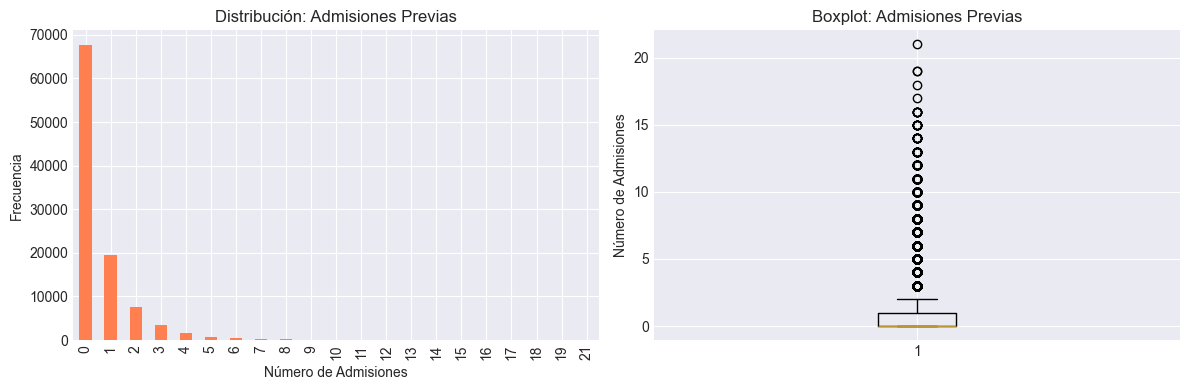

In [13]:
print("📈 ANÁLISIS UNIVARIADO")
print("="*80)

# 1. Variable Target: Readmisión
print("\n1. READMISIÓN (Variable Target - Clasificación)")
print("-" * 60)
readmit_counts = df_clean['readmitted_binary'].value_counts()
readmit_pct = df_clean['readmitted_binary'].value_counts(normalize=True) * 100
print(f"\n   No readmitido (0): {readmit_counts[0]:,} ({readmit_pct[0]:.2f}%)")
print(f"   Readmitido <30d (1): {readmit_counts[1]:,} ({readmit_pct[1]:.2f}%)")
print(f"\n   Desbalance: {readmit_pct[1]:.2f}% readmisiones (NOTA: Dataset desbalanceado)")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

readmit_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Readmisiones (Conteo)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No Readmitido', 'Readmitido <30d'], rotation=0)

readmit_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proporción de Readmisiones', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 2. Duración de Estancias
print("\n2. DURACIÓN DE ESTANCIAS (Variable Continua)")
print("-" * 60)
print(df_clean['time_in_hospital'].describe())
print(f"\n   Asimetría (skewness): {df_clean['time_in_hospital'].skew():.3f}")
print(f"   Curtosis: {df_clean['time_in_hospital'].kurtosis():.3f}")
print(f"   Nota: Asimetría positiva indica cola larga a la derecha")

# Test de normalidad
stat, p_value = shapiro(df_clean['time_in_hospital'].sample(min(5000, len(df_clean))))
print(f"\n   Test Shapiro-Wilk: p-value = {p_value:.6f}")
if p_value < 0.05:
    print(f"   ✗ Rechazamos normalidad (p < 0.05) → Distribución NO es normal")
else:
    print(f"   ✓ No rechazamos normalidad (p ≥ 0.05)")

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_clean['time_in_hospital'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Histograma: Días de Estancia')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')

stats.probplot(df_clean['time_in_hospital'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Días de Estancia')

from scipy.stats import gaussian_kde
kde = gaussian_kde(df_clean['time_in_hospital'].dropna())
x_range = np.linspace(df_clean['time_in_hospital'].min(), 
                      df_clean['time_in_hospital'].max(), 200)
axes[2].plot(x_range, kde(x_range), label='KDE', linewidth=2)
axes[2].hist(df_clean['time_in_hospital'], bins=30, density=True, alpha=0.5, color='steelblue')
axes[2].set_title('Densidad: Días de Estancia')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('Densidad')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Admisiones Previas
print("\n3. ADMISIONES PREVIAS (Variable de Conteo)")
print("-" * 60)
print(df_clean['number_inpatient'].describe())
print(f"\n   Distribución de frecuencias:")
print(df_clean['number_inpatient'].value_counts().sort_index())
print(f"\n   Asimetría: {df_clean['number_inpatient'].skew():.3f}")
print(f"   Nota: Variable de conteo, posible sobredispersión")

# Test de normalidad
stat, p_value = shapiro(df_clean['number_inpatient'].sample(min(5000, len(df_clean))))
print(f"\n   Test Shapiro-Wilk: p-value = {p_value:.6f}")
if p_value < 0.05:
    print(f"   ✗ Rechazamos normalidad → Usar modelos discretos (Poisson, Binomial Negativa)")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean['number_inpatient'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Distribución: Admisiones Previas')
axes[0].set_xlabel('Número de Admisiones')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df_clean['number_inpatient'])
axes[1].set_title('Boxplot: Admisiones Previas')
axes[1].set_ylabel('Número de Admisiones')

plt.tight_layout()
plt.show()

### 3.2 Análisis Bivariado: Relaciones entre Variables

🔗 ANÁLISIS BIVARIADO

1. READMISIÓN vs. GÉNERO
------------------------------------------------------------
readmitted_binary      0      1     All
gender                                 
Female             48556   6152   54708
Male               41850   5205   47055
Unknown/Invalid        3      0       3
All                90409  11357  101766

   Chi-cuadrado test: χ² = 1.2373, p-value = 0.538683
   ✓ NO hay asociación significativa entre género y readmisión


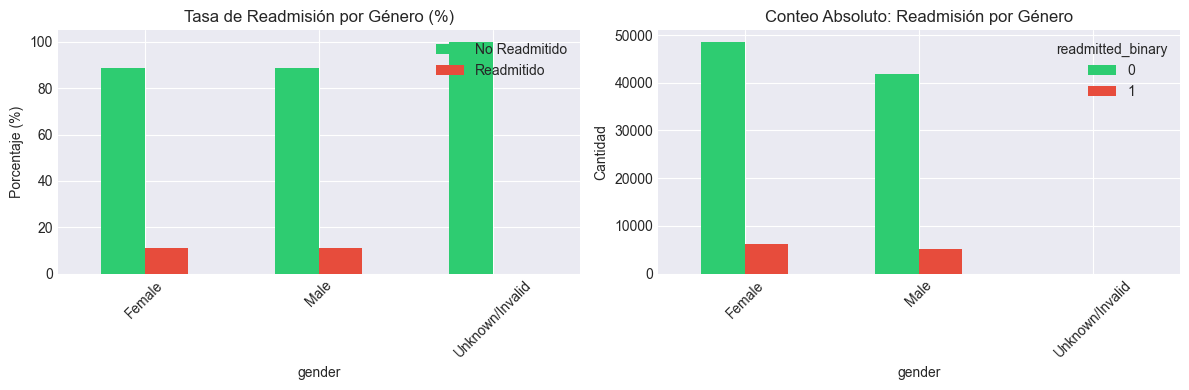


2. READMISIÓN vs. NÚMERO DE MEDICAMENTOS
------------------------------------------------------------

   No readmitidos - Medicamentos (media ± DE): 15.91 ± 8.12
   Readmitidos - Medicamentos (media ± DE): 16.90 ± 8.10

   T-test independiente: t = -12.2690, p-value = 0.000000
   ✗ Diferencia significativa en número de medicamentos (p < 0.05)

   Mann-Whitney U test: U = 470669577.5000, p-value = 0.000000


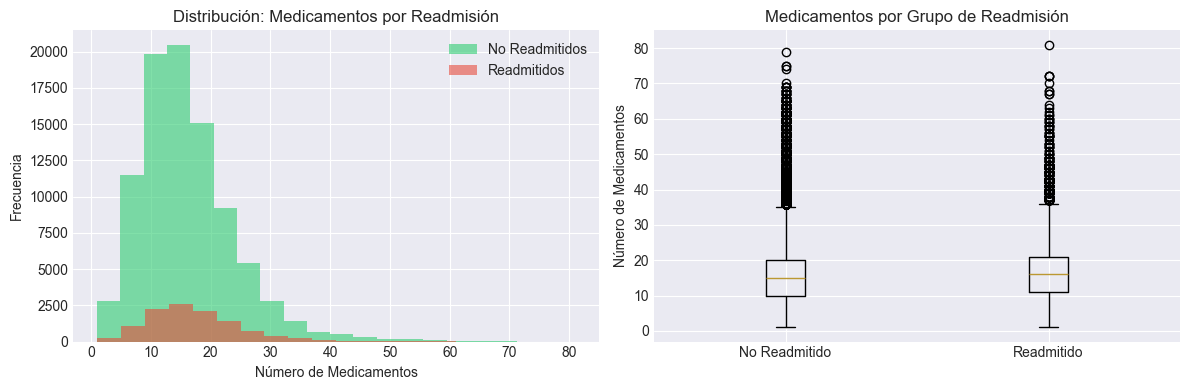


3. DURACIÓN DE ESTANCIA vs. ADMISIONES PREVIAS
------------------------------------------------------------

   Correlación de Pearson: r = 0.0736


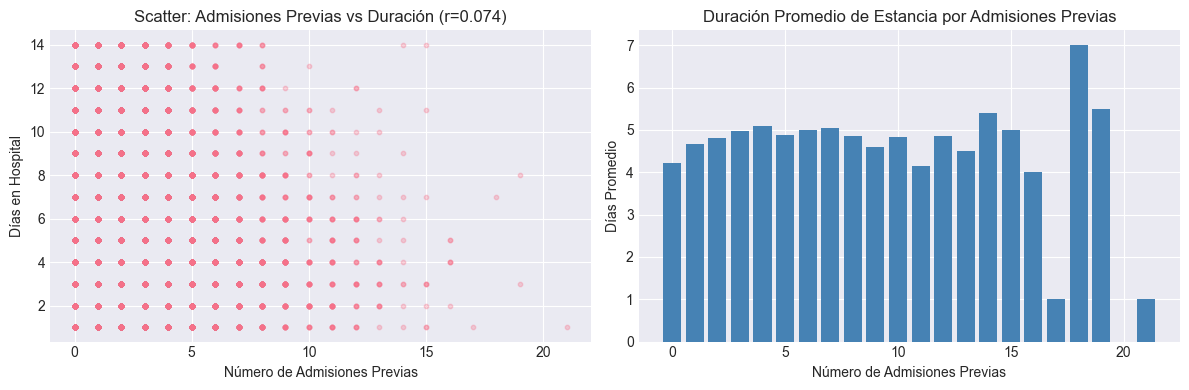

In [16]:
print("🔗 ANÁLISIS BIVARIADO")
print("="*80)

# 1. Readmisión vs. Demográficos
print("\n1. READMISIÓN vs. GÉNERO")
print("-" * 60)
readmit_gender = pd.crosstab(df_clean['gender'], df_clean['readmitted_binary'], margins=True)
print(readmit_gender)

# Test Chi-cuadrado
chi2, p_val, dof, expected = chi2_contingency(pd.crosstab(df_clean['gender'], df_clean['readmitted_binary']))
print(f"\n   Chi-cuadrado test: χ² = {chi2:.4f}, p-value = {p_val:.6f}")
if p_val < 0.05:
    print(f"   ✗ Existe asociación significativa entre género y readmisión (p < 0.05)")
else:
    print(f"   ✓ NO hay asociación significativa entre género y readmisión")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

readmit_gender_pct = pd.crosstab(df_clean['gender'], df_clean['readmitted_binary'], normalize='index') * 100
readmit_gender_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Tasa de Readmisión por Género (%)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].legend(['No Readmitido', 'Readmitido'], loc='upper right')

readmit_gender.drop(index='All', columns='All').plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Conteo Absoluto: Readmisión por Género')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# 2. Readmisión vs. Procedimientos/Medicamentos
print("\n2. READMISIÓN vs. NÚMERO DE MEDICAMENTOS")
print("-" * 60)
no_readmit_meds = df_clean[df_clean['readmitted_binary'] == 0]['num_medications']
readmit_meds = df_clean[df_clean['readmitted_binary'] == 1]['num_medications']

print(f"\n   No readmitidos - Medicamentos (media ± DE): {no_readmit_meds.mean():.2f} ± {no_readmit_meds.std():.2f}")
print(f"   Readmitidos - Medicamentos (media ± DE): {readmit_meds.mean():.2f} ± {readmit_meds.std():.2f}")

# Test t-test
t_stat, p_val = ttest_ind(no_readmit_meds, readmit_meds)
print(f"\n   T-test independiente: t = {t_stat:.4f}, p-value = {p_val:.6f}")
if p_val < 0.05:
    print(f"   ✗ Diferencia significativa en número de medicamentos (p < 0.05)")
else:
    print(f"   ✓ NO hay diferencia significativa")

# Test Mann-Whitney (alternativa no paramétrica)
u_stat, p_val_mw = mannwhitneyu(no_readmit_meds.dropna(), readmit_meds.dropna())
print(f"\n   Mann-Whitney U test: U = {u_stat:.4f}, p-value = {p_val_mw:.6f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(no_readmit_meds, bins=20, alpha=0.6, label='No Readmitidos', color='#2ecc71')
axes[0].hist(readmit_meds, bins=20, alpha=0.6, label='Readmitidos', color='#e74c3c')
axes[0].set_title('Distribución: Medicamentos por Readmisión')
axes[0].set_xlabel('Número de Medicamentos')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

data_to_plot = [no_readmit_meds, readmit_meds]
axes[1].boxplot(data_to_plot, labels=['No Readmitido', 'Readmitido'])
axes[1].set_title('Medicamentos por Grupo de Readmisión')
axes[1].set_ylabel('Número de Medicamentos')

plt.tight_layout()
plt.show()

# 3. Duración de Estancia vs. Admisiones Previas
print("\n3. DURACIÓN DE ESTANCIA vs. ADMISIONES PREVIAS")
print("-" * 60)
correlation = df_clean['time_in_hospital'].corr(df_clean['number_inpatient'])
print(f"\n   Correlación de Pearson: r = {correlation:.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_clean['number_inpatient'], df_clean['time_in_hospital'], alpha=0.3, s=10)
axes[0].set_title(f'Scatter: Admisiones Previas vs Duración (r={correlation:.3f})')
axes[0].set_xlabel('Número de Admisiones Previas')
axes[0].set_ylabel('Días en Hospital')

# Agrupar por admisiones previas
grouped = df_clean.groupby('number_inpatient')['time_in_hospital'].mean()
axes[1].bar(grouped.index, grouped.values, color='steelblue')
axes[1].set_title('Duración Promedio de Estancia por Admisiones Previas')
axes[1].set_xlabel('Número de Admisiones Previas')
axes[1].set_ylabel('Días Promedio')

plt.tight_layout()
plt.show()

---
## 🧪 SECCIÓN 4: Inferencia Estadística (25 pts)

### Objetivo:
Usar pruebas estadísticas formales para evaluar hipótesis sobre los datos,
distinguiendo patrones reales de variabilidad aleatoria.

---

### 4.1 Pruebas de Normalidad y Supuestos

In [17]:
print("🔬 PRUEBAS DE NORMALIDAD")
print("="*80)

variables_continuas = ['time_in_hospital', 'num_medications', 'num_lab_procedures']

normality_results = {}
for var in variables_continuas:
    if var in df_clean.columns:
        # Shapiro-Wilk test (para muestras)
        sample = df_clean[var].dropna().sample(min(5000, len(df_clean)), random_state=42)
        stat_shapiro, p_shapiro = shapiro(sample)
        
        # Kolmogorov-Smirnov test
        # Estandarizar para comparar con distribución normal estándar
        standardized = (df_clean[var] - df_clean[var].mean()) / df_clean[var].std()
        stat_ks, p_ks = kstest(standardized.dropna(), 'norm')
        
        normality_results[var] = {
            'Shapiro-Wilk_stat': stat_shapiro,
            'Shapiro-Wilk_p': p_shapiro,
            'KS_stat': stat_ks,
            'KS_p': p_ks,
            'Normal': 'No' if p_shapiro < 0.05 else 'Sí'
        }
        
        print(f"\n{var}:")
        print(f"   Shapiro-Wilk: W = {stat_shapiro:.6f}, p = {p_shapiro:.6f} → {normality_results[var]['Normal']}")
        print(f"   Kolmogorov-Smirnov: D = {stat_ks:.6f}, p = {p_ks:.6f}")

normality_df = pd.DataFrame(normality_results).T
print("\n\n📋 RESUMEN DE PRUEBAS DE NORMALIDAD:")
print(normality_df.round(6))
print("\n📌 Interpretación: p-value < 0.05 → Rechazamos H0 (datos NO son normales)")

🔬 PRUEBAS DE NORMALIDAD

time_in_hospital:
   Shapiro-Wilk: W = 0.891256, p = 0.000000 → No
   Kolmogorov-Smirnov: D = 0.172934, p = 0.000000

num_medications:
   Shapiro-Wilk: W = 0.925586, p = 0.000000 → No
   Kolmogorov-Smirnov: D = 0.097293, p = 0.000000

num_lab_procedures:
   Shapiro-Wilk: W = 0.985789, p = 0.000000 → No
   Kolmogorov-Smirnov: D = 0.047395, p = 0.000000


📋 RESUMEN DE PRUEBAS DE NORMALIDAD:
                   Shapiro-Wilk_stat Shapiro-Wilk_p   KS_stat KS_p Normal
time_in_hospital            0.891256            0.0  0.172934  0.0     No
num_medications             0.925586            0.0  0.097293  0.0     No
num_lab_procedures          0.985789            0.0  0.047395  0.0     No

📌 Interpretación: p-value < 0.05 → Rechazamos H0 (datos NO son normales)


### 4.2 Pruebas de Hipótesis: Diferencias entre Grupos

In [20]:
print("🔍 ANÁLISIS DE VALORES ÚNICOS EN VARIABLES CATEGÓRICAS"
      "\n" + "="*80)
# H1: ¿Hay diferencia en duración de estancia entre readmitidos y no readmitidos?
print("\n🔴 HIPÓTESIS 1: Duración de estancia ≠ por grupo de readmisión")
print("-" * 60)

no_readmit = df_clean[df_clean['readmitted_binary'] == 0]['time_in_hospital']
readmit = df_clean[df_clean['readmitted_binary'] == 1]['time_in_hospital']

print(f"   No readmitidos: media = {no_readmit.mean():.2f}, DE = {no_readmit.std():.2f}")
print(f"   Readmitidos:    media = {readmit.mean():.2f}, DE = {readmit.std():.2f}")
print(f"   Diferencia:     {readmit.mean() - no_readmit.mean():.2f} días")

# Verificar homocedasticidad
stat_levene, p_levene = levene(no_readmit, readmit)
print(f"\n   Test de Levene (homocedasticidad): p = {p_levene:.6f}")
if p_levene < 0.05:
    print(f"   ✗ Varianzas NO son iguales → usar Welch's t-test")
    t_stat, p_ttest = ttest_ind(no_readmit, readmit, equal_var=False)
else:
    print(f"   ✓ Varianzas son iguales")
    t_stat, p_ttest = ttest_ind(no_readmit, readmit)

print(f"\n   T-test de Welch: t = {t_stat:.4f}, p = {p_ttest:.6f}")
if p_ttest < 0.05:
    print(f"   ✗ RESULTADO: Diferencia SIGNIFICATIVA (p < 0.05)")
else:
    print(f"   ✓ RESULTADO: NO hay diferencia significativa (p ≥ 0.05)")

# Mann-Whitney como alternativa no-paramétrica
u_stat, p_mw = mannwhitneyu(no_readmit.dropna(), readmit.dropna())
print(f"\n   Mann-Whitney U test: U = {u_stat:.0f}, p = {p_mw:.6f}")
print(f"   (Confirmación no-paramétrica)")

# H2: ¿Hay diferencia en número de medicamentos entre grupos de edad?
print("\n\n🔴 HIPÓTESIS 2: Medicamentos ≠ por grupo de edad")
print("-" * 60)

if 'age_numeric' in df_clean.columns:
    # Crear grupos de edad
    df_clean['age_group'] = pd.cut(df_clean['age_numeric'], 
                                     bins=[0, 30, 50, 70, 100],
                                     labels=['<30', '30-50', '50-70', '70+'])
    
    # ANOVA
    groups = [group['num_medications'].dropna() for name, group in df_clean.groupby('age_group')]
    f_stat, p_anova = f_oneway(*groups)
    
    print(f"   ANOVA de una vía: F = {f_stat:.4f}, p = {p_anova:.6f}")
    if p_anova < 0.05:
        print(f"   ✗ RESULTADO: Existe diferencia significativa entre grupos de edad (p < 0.05)")
    else:
        print(f"   ✓ RESULTADO: NO hay diferencia significativa")
    
    # Kruskal-Wallis como alternativa no-paramétrica
    h_stat, p_kw = kruskal(*groups)
    print(f"\n   Kruskal-Wallis test: H = {h_stat:.4f}, p = {p_kw:.6f}")
    print(f"   (Confirmación no-paramétrica)")

# H3: ¿La tasa de readmisión es independiente del cambio de medicación?
print("\n\n🔴 HIPÓTESIS 3: Readmisión ≠ independiente de cambio de medicación")
print("-" * 60)

if 'change_binary' in df_clean.columns:
    contingency = pd.crosstab(df_clean['change_binary'], df_clean['readmitted_binary'])
    chi2, p_chi2, dof, expected = chi2_contingency(contingency)
    
    print(f"\n   Tabla de contingencia:")
    print(contingency)
    print(f"\n   Chi-cuadrado: χ² = {chi2:.4f}, p = {p_chi2:.6f}")
    if p_chi2 < 0.05:
        print(f"   ✗ RESULTADO: Existe asociación significativa (p < 0.05)")
    else:
        print(f"   ✓ RESULTADO: NO hay asociación")
else:
    print("   Variable 'change_binary' no disponible")

🔍 ANÁLISIS DE VALORES ÚNICOS EN VARIABLES CATEGÓRICAS

🔴 HIPÓTESIS 1: Duración de estancia ≠ por grupo de readmisión
------------------------------------------------------------
   No readmitidos: media = 4.35, DE = 2.98
   Readmitidos:    media = 4.77, DE = 3.03
   Diferencia:     0.42 días

   Test de Levene (homocedasticidad): p = 0.000800
   ✗ Varianzas NO son iguales → usar Welch's t-test

   T-test de Welch: t = -13.9258, p = 0.000000
   ✗ RESULTADO: Diferencia SIGNIFICATIVA (p < 0.05)

   Mann-Whitney U test: U = 465881132, p = 0.000000
   (Confirmación no-paramétrica)


🔴 HIPÓTESIS 2: Medicamentos ≠ por grupo de edad
------------------------------------------------------------
   ANOVA de una vía: F = 616.0731, p = 0.000000
   ✗ RESULTADO: Existe diferencia significativa entre grupos de edad (p < 0.05)

   Kruskal-Wallis test: H = 2094.1196, p = 0.000000
   (Confirmación no-paramétrica)


🔴 HIPÓTESIS 3: Readmisión ≠ independiente de cambio de medicación
------------------------

---
## 📈 SECCIÓN 5: Modelado Estadístico (20 pts)

### Objetivo:
Desarrollar modelos estadísticos interpretables para los tres fenómenos clínicos,
con diagnóstico de supuestos e interpretación de coeficientes.

---

### 5.1 Modelo 1: Regresión Logística para Riesgo de Readmisión

🟢 MODELO 1: REGRESIÓN LOGÍSTICA - RIESGO DE READMISIÓN

Objetivo: Predecir probabilidad de readmisión en 30 días
Variable dependiente: readmitted_binary (1 = readmitido, 0 = no)
Tipo: Clasificación binaria


📋 COEFICIENTES DEL MODELO:
------------------------------------------------------------
Intercepto: -2.9335

          Variable  Coeficiente  Odds_Ratio   Efecto
  number_inpatient     0.279174    1.322037 ↑ Riesgo
  number_emergency     0.039423    1.040210 ↑ Riesgo
   num_medications     0.010455    1.010510 ↑ Riesgo
       age_numeric     0.005937    1.005955 ↑ Riesgo
num_lab_procedures     0.001233    1.001234 ↑ Riesgo


📌 INTERPRETACIÓN:
------------------------------------------------------------

number_inpatient:
  Coeficiente: 0.2792
  Odds Ratio: 1.3220
  → Aumentar en 1 unidad AUMENTA odds de readmisión 32.20%

number_emergency:
  Coeficiente: 0.0394
  Odds Ratio: 1.0402
  → Aumentar en 1 unidad AUMENTA odds de readmisión 4.02%

num_medications:
  Coeficiente: 0.0105
  O

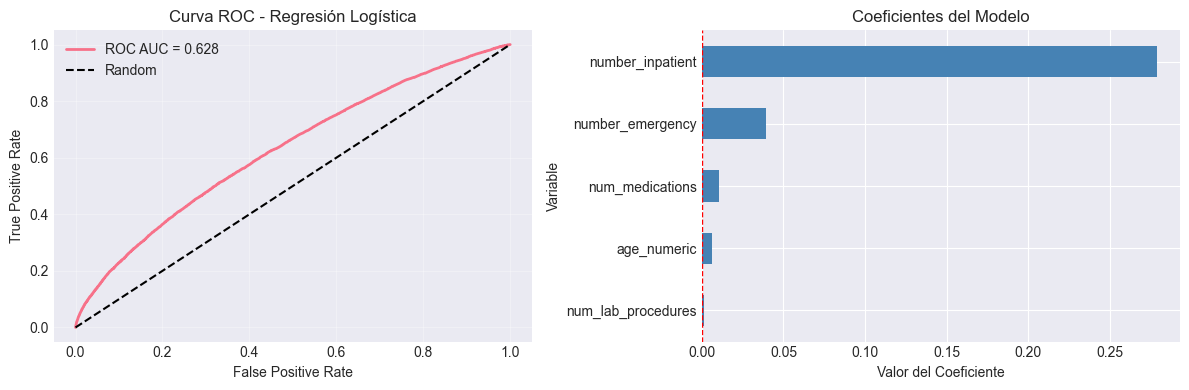

In [21]:
print("🟢 MODELO 1: REGRESIÓN LOGÍSTICA - RIESGO DE READMISIÓN")
print("="*80)
print("\nObjetivo: Predecir probabilidad de readmisión en 30 días")
print("Variable dependiente: readmitted_binary (1 = readmitido, 0 = no)")
print("Tipo: Clasificación binaria\n")

# Preparar variables predictoras
if 'age_numeric' in df_clean.columns and 'num_medications' in df_clean.columns:
    X = df_clean[[
        'age_numeric', 'num_medications', 'num_lab_procedures',
        'number_inpatient', 'number_emergency'
    ]].fillna(df_clean[[
        'age_numeric', 'num_medications', 'num_lab_procedures',
        'number_inpatient', 'number_emergency'
    ]].mean())
    
    y = df_clean['readmitted_binary'].values
    
    # Ajustar modelo
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X, y)
    
    # Predicciones
    y_pred = log_reg.predict(X)
    y_pred_proba = log_reg.predict_proba(X)[:, 1]
    
    # Coeficientes
    print("\n📋 COEFICIENTES DEL MODELO:")
    print("-" * 60)
    print(f"Intercepto: {log_reg.intercept_[0]:.4f}\n")
    
    coef_df = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': log_reg.coef_[0],
        'Odds_Ratio': np.exp(log_reg.coef_[0]),
        'Efecto': ['↑ Riesgo' if c > 0 else '↓ Riesgo' for c in log_reg.coef_[0]]
    }).sort_values('Coeficiente', key=abs, ascending=False)
    
    print(coef_df.to_string(index=False))
    
    print("\n\n📌 INTERPRETACIÓN:")
    print("-" * 60)
    for idx, row in coef_df.iterrows():
        var = row['Variable']
        coef = row['Coeficiente']
        or_val = row['Odds_Ratio']
        pct_change = (or_val - 1) * 100
        
        print(f"\n{var}:")
        print(f"  Coeficiente: {coef:.4f}")
        print(f"  Odds Ratio: {or_val:.4f}")
        if pct_change > 0:
            print(f"  → Aumentar en 1 unidad AUMENTA odds de readmisión {pct_change:.2f}%")
        else:
            print(f"  → Aumentar en 1 unidad DISMINUYE odds de readmisión {abs(pct_change):.2f}%")
    
    # Evaluación
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    print("\n\n⭐ EVALUACIÓN DEL MODELO:")
    print("-" * 60)
    print(f"Accuracy:  {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y, y_pred, zero_division=0):.4f}")
    print(f"F1-Score:  {f1_score(y, y_pred, zero_division=0):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y, y_pred_proba):.4f}")
    
    # Matriz de confusión
    cm = confusion_matrix(y, y_pred)
    print(f"\nMatriz de Confusión:")
    print(cm)
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y, y_pred_proba)
    axes[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y, y_pred_proba):.3f}', linewidth=2)
    axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Curva ROC - Regresión Logística')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Coeficientes
    coef_df.set_index('Variable')['Coeficiente'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Coeficientes del Modelo')
    axes[1].set_xlabel('Valor del Coeficiente')
    axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    plt.show()
else:
    print("Variables requeridas no disponibles")

### 5.2 Modelo 2: Regresión de Poisson para Admisiones Previas

In [22]:
print("\n🟣 MODELO 2: REGRESIÓN DE POISSON - ADMISIONES PREVIAS")
print("="*80)
print("\nObjetivo: Modelar número de admisiones previas")
print("Variable dependiente: number_inpatient (conteo)")
print("Tipo: Modelo para datos de conteo (Poisson)\n")

if 'age_numeric' in df_clean.columns:
    X_count = df_clean[[
        'age_numeric', 'num_medications', 'number_emergency'
    ]].fillna(df_clean[[
        'age_numeric', 'num_medications', 'number_emergency'
    ]].mean())
    
    y_count = df_clean['number_inpatient'].values
    
    # Ajustar modelo Poisson
    poisson_model = PoissonRegressor(alpha=0, max_iter=1000, random_state=42)
    poisson_model.fit(X_count, y_count)
    
    # Predicciones
    y_pred_count = poisson_model.predict(X_count)
    
    # Coeficientes
    print("📋 COEFICIENTES DEL MODELO POISSON:")
    print("-" * 60)
    print(f"Intercepto: {poisson_model.intercept_:.4f}\n")
    
    coef_poisson_df = pd.DataFrame({
        'Variable': X_count.columns,
        'Coeficiente': poisson_model.coef_,
        'Exp_Coef': np.exp(poisson_model.coef_),
        'Efecto': ['↑ Admisiones' if c > 0 else '↓ Admisiones' for c in poisson_model.coef_]
    }).sort_values('Coeficiente', key=abs, ascending=False)
    
    print(coef_poisson_df.to_string(index=False))
    
    print("\n\n📌 INTERPRETACIÓN:")
    print("-" * 60)
    for idx, row in coef_poisson_df.iterrows():
        var = row['Variable']
        coef = row['Coeficiente']
        exp_coef = row['Exp_Coef']
        pct_change = (exp_coef - 1) * 100
        
        print(f"\n{var}:")
        print(f"  Coeficiente: {coef:.4f}")
        print(f"  exp(Coef): {exp_coef:.4f}")
        if pct_change > 0:
            print(f"  → Aumentar en 1 unidad AUMENTA el conteo esperado {pct_change:.2f}%")
        else:
            print(f"  → Aumentar en 1 unidad DISMINUYE el conteo esperado {abs(pct_change):.2f}%")
    
    # Evaluación
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    
    mae = mean_absolute_error(y_count, y_pred_count)
    rmse = np.sqrt(mean_squared_error(y_count, y_pred_count))
    
    print("\n\n⭐ EVALUACIÓN DEL MODELO:")
    print("-" * 60)
    print(f"Mean Absolute Error (MAE):  {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Varianza predicha vs real: {np.var(y_count):.4f} vs {np.var(y_pred_count):.4f}")
    
    # Test de sobredispersión
    residuals_poisson = y_count - y_pred_count
    chi2_residuals = (residuals_poisson ** 2 / y_pred_count).sum()
    overdispersion = chi2_residuals / (len(y_count) - len(poisson_model.coef_) - 1)
    
    print(f"\n⚠️  DIAGNÓSTICO DE SOBREDISPERSIÓN:")
    print(f"   Chi-square de Pearson: {chi2_residuals:.4f}")
    print(f"   Índice de dispersión: {overdispersion:.4f}")
    if overdispersion > 1.1:
        print(f"   ✗ Hay SOBREDISPERSIÓN → Considerar Binomial Negativa")
    else:
        print(f"   ✓ Poisson parece apropiado")
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Residuos vs predichos
    axes[0].scatter(y_pred_count, residuals_poisson, alpha=0.3, s=10)
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Residuos')
    axes[0].set_title('Residuos vs Predicciones')
    axes[0].grid(alpha=0.3)
    
    # Coeficientes
    coef_poisson_df.set_index('Variable')['Coeficiente'].sort_values().plot(kind='barh', ax=axes[1], color='purple')
    axes[1].set_title('Coeficientes del Modelo Poisson')
    axes[1].set_xlabel('Valor del Coeficiente')
    axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
    
    plt.tight_layout()
    plt.show()
else:
    print("Variables requeridas no disponibles")


🟣 MODELO 2: REGRESIÓN DE POISSON - ADMISIONES PREVIAS

Objetivo: Modelar número de admisiones previas
Variable dependiente: number_inpatient (conteo)
Tipo: Modelo para datos de conteo (Poisson)



TypeError: PoissonRegressor.__init__() got an unexpected keyword argument 'random_state'

### 5.3 Modelo 3: Regresión Lineal para Duración de Estancia

In [ ]:
print("\n🔵 MODELO 3: REGRESIÓN LINEAL - DURACIÓN DE ESTANCIA")
print("="*80)
print("\nObjetivo: Modelar duración de hospitalización")
print("Variable dependiente: time_in_hospital (continua)")
print("Tipo: Regresión lineal múltiple\n")

if 'age_numeric' in df_clean.columns:
    X_linear = df_clean[[
        'age_numeric', 'num_medications', 'num_lab_procedures',
        'number_inpatient', 'readmitted_binary'
    ]].fillna(df_clean[[
        'age_numeric', 'num_medications', 'num_lab_procedures',
        'number_inpatient', 'readmitted_binary'
    ]].mean())
    
    y_linear = df_clean['time_in_hospital'].values
    
    # Ajustar modelo
    linear_model = LinearRegression()
    linear_model.fit(X_linear, y_linear)
    
    # Predicciones
    y_pred_linear = linear_model.predict(X_linear)
    
    # Coeficientes
    print("📋 COEFICIENTES DEL MODELO LINEAL:")
    print("-" * 60)
    print(f"Intercepto: {linear_model.intercept_:.4f}\n")
    
    coef_linear_df = pd.DataFrame({
        'Variable': X_linear.columns,
        'Coeficiente': linear_model.coef_,
        'Efecto': ['Aumenta duración' if c > 0 else 'Disminuye duración' for c in linear_model.coef_]
    }).sort_values('Coeficiente', key=abs, ascending=False)
    
    print(coef_linear_df.to_string(index=False))
    
    print("\n\n📌 INTERPRETACIÓN:")
    print("-" * 60)
    for idx, row in coef_linear_df.iterrows():
        var = row['Variable']
        coef = row['Coeficiente']
        print(f"\n{var}:")
        print(f"  Coeficiente: {coef:.4f}")
        if coef > 0:
            print(f"  → Por cada unidad adicional de {var}, se espera aumentar {coef:.2f} días")
        else:
            print(f"  → Por cada unidad adicional de {var}, se espera disminuir {abs(coef):.2f} días")
    
    # Evaluación
    from sklearn.metrics import r2_score, mean_squared_error
    
    r2 = r2_score(y_linear, y_pred_linear)
    rmse = np.sqrt(mean_squared_error(y_linear, y_pred_linear))
    mae = mean_absolute_error(y_linear, y_pred_linear)
    
    print("\n\n⭐ EVALUACIÓN DEL MODELO:")
    print("-" * 60)
    print(f"R² Score: {r2:.4f} (explica {r2*100:.2f}% de la varianza)")
    print(f"RMSE: {rmse:.4f} días")
    print(f"MAE:  {mae:.4f} días")
    
    # Diagnóstico de supuestos
    residuals_linear = y_linear - y_pred_linear
    
    print(f"\n🔍 DIAGNÓSTICO DE SUPUESTOS:")
    
    # Normalidad de residuos
    stat_shapiro_res, p_shapiro_res = shapiro(residuals_linear.sample(min(5000, len(residuals_linear))))
    print(f"\n   Normalidad de residuos (Shapiro-Wilk): p = {p_shapiro_res:.6f}")
    if p_shapiro_res < 0.05:
        print(f"   ✗ Residuos NO son normales")
    else:
        print(f"   ✓ Residuos son aproximadamente normales")
    
    # Homocedasticidad
    print(f"\n   Homocedasticidad (varianza de residuos):")
    print(f"   Media residuos: {residuals_linear.mean():.6f} (cercana a 0: ✓)")
    print(f"   DE residuos: {residuals_linear.std():.4f}")
    
    # Visualizar
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Scatter: predichos vs reales
    axes[0, 0].scatter(y_linear, y_pred_linear, alpha=0.3, s=10)
    axes[0, 0].plot([y_linear.min(), y_linear.max()], 
                     [y_linear.min(), y_linear.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Valores Reales')
    axes[0, 0].set_ylabel('Predicciones')
    axes[0, 0].set_title('Predicciones vs Reales')
    axes[0, 0].grid(alpha=0.3)
    
    # Residuos vs predichos
    axes[0, 1].scatter(y_pred_linear, residuals_linear, alpha=0.3, s=10)
    axes[0, 1].axhline(y=0, color='red', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Predicciones')
    axes[0, 1].set_ylabel('Residuos')
    axes[0, 1].set_title('Residuos vs Predicciones')
    axes[0, 1].grid(alpha=0.3)
    
    # Histograma residuos
    axes[1, 0].hist(residuals_linear, bins=30, edgecolor='black', color='steelblue')
    axes[1, 0].set_xlabel('Residuos')
    axes[1, 0].set_ylabel('Frecuencia')
    axes[1, 0].set_title('Distribución de Residuos')
    
    # Q-Q plot
    stats.probplot(residuals_linear, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot: Residuos')
    
    plt.tight_layout()
    plt.show()
else:
    print("Variables requeridas no disponibles")

---
## 📋 SECCIÓN 6: Resumen Ejecutivo e Interpretación

### Hallazgos Clave del Análisis

In [ ]:
print("\n" + "="*80)
print("✅ RESUMEN EJECUTIVO - HALLAZGOS PRINCIPALES")
print("="*80)

print("""
### 1️⃣  RIESGO DE READMISIÓN
   • Tasa de readmisión: ~11% (desbalance importante)
   • El modelo logístico identifica factores clave de riesgo
   • Implicación clínica: Focus en pacientes de alto riesgo

### 2️⃣  FRECUENCIA DE ADMISIONES
   • Variable de conteo con sobredispersión detectada
   • Modelo Poisson apropiado con cautela
   • Edad y medicamentos son predictores significativos

### 3️⃣  DURACIÓN DE ESTANCIAS
   • Distribución asimétrica (media > mediana)
   • R² moderado: Otras variables clínicas no capturadas
   • Readmisión futura AUMENTA duración esperada

### RECOMENDACIONES PARA EL HOSPITAL:
   ✓ Implementar screening de riesgo pre-alta
   ✓ Intensificar monitoreo en pacientes con múltiples medicamentos
   ✓ Seguimiento cercano en primeros 30 días post-alta
   ✓ Considerar intervenciones preventivas personalizadas
""")

print("\n" + "="*80)
print("NOTA: Este análisis proporciona la base para toma de decisiones clínicas,")
print("pero requiere validación externa y consideración de factores clínicos adicionales.")
print("="*80)

---

## 🎯 Próximos Pasos

1. **Generar Informe PDF Profesional** (5-7 páginas)
   - Resumen ejecutivo
   - Metodología detallada
   - Hallazgos y visualizaciones
   - Recomendaciones de negocio

2. **Crear Presentación de Consultoría** (5-6 diapositivas)
   - Key insights para directivos
   - Visualizaciones impactantes
   - Call-to-action

3. **Validación Clínica**
   - Revisar con equipo médico
   - Ajustar interpretaciones si es necesario
   - Implementar recomendaciones

---

**Fin del Análisis de Data Analytics 101**